# Cardiopulmonary Digital Twin — Analysis Notebook
### MIMIC-IV Heart-Lung Coupling Analysis

**Author:** Cardiopulmonary Digital Twin Research Group  
**Platform:** Python 3.10+ · neurokit2 · scipy · PyTorch  
**Data:** MIMIC-IV Waveform Database (PhysioNet) / Synthetic Demo

---

This notebook demonstrates:
1. Engine initialisation and session replay from `session_log.csv`
2. Vital signs trend analysis with clinical annotation
3. HRV time-domain and frequency-domain analysis
4. Heart-lung coupling metrics (RSA amplitude, Phase Synchronisation Index, XCorr)
5. O₂ delivery index and physiological stress load
6. Predictive alert analysis and ETA timeline
7. Statistical summary and clinical interpretation
8. Live engine demonstration with a 5-minute synthetic hypoxia scenario


## 1 · Setup and Imports

In [1]:
import sys
from pathlib import Path

# Dynamically find the root directory containing 'src'
current_dir = Path.cwd()
if (current_dir / 'src').exists():
    root_dir = current_dir
elif (current_dir.parent / 'src').exists():
    root_dir = current_dir.parent
else:
    root_dir = current_dir

if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

print(f"Project root set to: {root_dir}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy import signal as sp_signal
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# Plotly for interactive figures
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Twin modules
from src.core.twin_engine import TwinEngine
from src.core.config import load_config

# Aesthetics
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#8b949e',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#e6edf3',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'lines.linewidth':  1.8,
    'font.family':      'monospace',
})

C = {'hr': '#fb923c', 'spo2': '#f472b6', 'rr': '#38bdf8', 'o2d': '#4ade80',
     'rmssd': '#bc8cff', 'stress': '#fbbf24', 'rsa': '#d29922',
     'psi': '#3fb950', 'xcorr': '#58a6ff'}

print('✓ Imports successful')
print(f'  NumPy   {np.__version__}')
print(f'  Pandas  {pd.__version__}')
import scipy
print(f'  SciPy   {scipy.__version__}')
import plotly.io as pio
pio.renderers.default = 'vscode'


Project root set to: c:\Users\Admin\Documents\CARDIOPULMONARY TWIN
✓ Imports successful
  NumPy   2.4.5
  Pandas  2.3.3
  SciPy   1.17.1


## 2 · Load Session Log from session_log.csv

In [2]:
LOG_FILE = '../session_log.csv'

df = pd.read_csv(LOG_FILE, parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

# Derived time axis in seconds from session start
t0 = df['timestamp'].iloc[0]
df['t_s'] = (df['timestamp'] - t0).dt.total_seconds()

print(f'Session log loaded: {len(df)} records')
print(f'Duration: {df["t_s"].max():.1f} seconds ({df["t_s"].max()/60:.1f} minutes)')
print(f'\nColumns: {list(df.columns)}')
print(f'\nData head:')
display(df[['t_s','heart_rate','respiratory_rate','spo2','o2_delivery_index',
            'stability_index','rsa_amplitude','psi','xcorr_peak','stress_load']].head(10).round(3))


Session log loaded: 1200 records
Duration: 8.8 seconds (0.1 minutes)

Columns: ['timestamp', 'subject_id', 'heart_rate', 'respiratory_rate', 'spo2', 'rmssd', 'sdnn', 'lf_hf_ratio', 'o2_delivery_index', 'stability_index', 'stress_load', 'rsa_amplitude', 'xcorr_peak', 'psi', 'hypoxia_blunted', 'eta_spo2_critical_s', 'eta_hr_critical_s', 'n_alerts', 't_s']

Data head:


,t_s,heart_rate,respiratory_rate,spo2,o2_delivery_index,stability_index,rsa_amplitude,psi,xcorr_peak,stress_load
0,0.000,0.0,15.0,98.0,0.0,0.394,0.0,0.984,0.0,50.0
1,0.003,0.0,15.0,98.0,0.0,0.249,0.0,0.622,0.0,50.0
2,0.004,0.0,15.0,98.0,0.0,0.246,0.0,0.614,0.0,50.0
3,0.007,0.0,15.0,98.0,0.0,0.224,0.0,0.559,0.0,50.0
4,0.009,0.0,15.0,98.0,0.0,0.026,0.0,0.065,0.0,50.0
5,0.011,0.0,15.0,98.0,0.0,0.027,0.0,0.068,0.0,50.0
6,0.012,0.0,15.0,98.0,0.0,0.032,0.0,0.081,0.0,50.0
7,0.014,0.0,15.0,98.0,0.0,0.161,0.0,0.403,0.0,50.0
8,0.016,0.0,27.8,98.0,0.0,0.141,0.0,0.353,0.0,57.8
9,0.017,0.0,25.0,98.0,0.0,0.130,0.0,0.325,0.0,55.0


## 3 · Statistical Summary

In [3]:
cols = ['heart_rate','respiratory_rate','spo2','rmssd','sdnn',
        'o2_delivery_index','stability_index','stress_load',
        'rsa_amplitude','psi','xcorr_peak']

summary = df[cols].describe().round(3)
summary.index.name = 'Statistic'
print('=== SESSION STATISTICS ===')
display(summary)

print('\n=== CLINICAL INTERPRETATION ===')
hr_mean = df['heart_rate'].mean()
spo2_min = df['spo2'].min()
rmssd_mean = df['rmssd'].mean()
psi_mean = df['psi'].mean()
stress_max = df['stress_load'].max()
o2d_min = df['o2_delivery_index'].min()

print(f'  Mean HR:          {hr_mean:.1f} bpm  ({"Normal" if 60<=hr_mean<=100 else "Abnormal"})')
print(f'  Min SpO₂:         {spo2_min:.1f} %    ({"CRITICAL" if spo2_min<90 else "Warning" if spo2_min<94 else "Normal"})')
print(f'  Mean RMSSD:       {rmssd_mean:.1f} ms  ({"Normal" if rmssd_mean>=20 else "Reduced autonomic tone"})')
print(f'  Mean PSI:         {psi_mean:.3f}     ({"Strong coupling" if psi_mean>0.6 else "Moderate" if psi_mean>0.3 else "Weak coupling"})')
print(f'  Max Stress Load:  {stress_max:.0f}/100  ({"High" if stress_max>75 else "Moderate" if stress_max>50 else "Low"})')
print(f'  Min O₂ Delivery:  {o2d_min:.3f}     ({"CRITICAL" if o2d_min<0.6 else "Warning" if o2d_min<0.8 else "Adequate"})')


=== SESSION STATISTICS ===


,heart_rate,respiratory_rate,spo2,rmssd,sdnn,o2_delivery_index,stability_index,stress_load,rsa_amplitude,psi,xcorr_peak
Statistic,,,,,,,,,,,
count,1200.0,1200.000,1200.000,1200.0,1200.0,1200.0,1200.000,1200.000,1200.0,1200.000,1200.0
mean,0.0,15.610,97.956,0.0,0.0,0.0,0.031,50.385,0.0,0.078,0.0
std,0.0,0.648,0.219,0.0,0.0,0.0,0.028,0.466,0.0,0.069,0.0
min,0.0,10.000,97.700,0.0,0.0,0.0,0.000,50.000,0.0,0.001,0.0
25%,0.0,15.600,97.800,0.0,0.0,0.0,0.018,50.000,0.0,0.045,0.0
50%,0.0,15.600,97.900,0.0,0.0,0.0,0.028,50.300,0.0,0.070,0.0
75%,0.0,15.600,98.200,0.0,0.0,0.0,0.038,50.600,0.0,0.096,0.0
max,0.0,27.800,98.300,0.0,0.0,0.0,0.394,57.800,0.0,0.984,0.0



=== CLINICAL INTERPRETATION ===
  Mean HR:          0.0 bpm  (Abnormal)
  Min SpO₂:         97.7 %    (Normal)
  Mean RMSSD:       0.0 ms  (Reduced autonomic tone)
  Mean PSI:         0.078     (Weak coupling)
  Max Stress Load:  58/100  (Moderate)
  Min O₂ Delivery:  0.000     (CRITICAL)


## 4 · Vital Signs Trend Analysis

In [4]:
fig = make_subplots(
    rows=4, cols=1, shared_xaxes=True, vertical_spacing=0.04,
    subplot_titles=[
        'Heart Rate (bpm)',
        'Respiratory Rate (br/min)',
        'SpO₂ (%)',
        'O₂ Delivery Index',
    ]
)

DARK = '#0d1117'; CARD = '#161b22'; BD = '#30363d'; TX = '#e6edf3'; TX2 = '#8b949e'

def add_thline(fig, y, row, color='rgba(248,81,73,0.6)', dash='dot'):
    fig.add_hline(y=y, line_dash=dash, line_color=color, line_width=1.2, row=row, col="all")  # type: ignore

# HR
fig.add_trace(go.Scatter(x=df['t_s'], y=df['heart_rate'],
    line=dict(color=C['hr'], width=1.6), fill='tozeroy',
    fillcolor='rgba(251,146,60,0.08)', name='HR'), row=1, col=1)
add_thline(fig, 140, 1); add_thline(fig, 110, 1, 'rgba(210,153,34,0.7)')
add_thline(fig, 40,  1); add_thline(fig, 55,  1, 'rgba(210,153,34,0.7)')

# RR
fig.add_trace(go.Scatter(x=df['t_s'], y=df['respiratory_rate'],
    line=dict(color=C['rr'], width=1.6), fill='tozeroy',
    fillcolor='rgba(56,189,248,0.08)', name='RR'), row=2, col=1)
add_thline(fig, 30, 2); add_thline(fig, 8, 2)

# SpO2
fig.add_trace(go.Scatter(x=df['t_s'], y=df['spo2'],
    line=dict(color=C['spo2'], width=1.6), fill='tozeroy',
    fillcolor='rgba(244,114,182,0.08)', name='SpO₂'), row=3, col=1)
add_thline(fig, 90, 3); add_thline(fig, 94, 3, 'rgba(210,153,34,0.7)')

# O2 Delivery
fig.add_trace(go.Scatter(x=df['t_s'], y=df['o2_delivery_index'],
    line=dict(color=C['o2d'], width=1.6), fill='tozeroy',
    fillcolor='rgba(74,222,128,0.08)', name='O₂D'), row=4, col=1)
add_thline(fig, 0.60, 4); add_thline(fig, 0.80, 4, 'rgba(210,153,34,0.7)')

fig.update_xaxes(showgrid=True, gridcolor=BD, zeroline=False, color=TX2, title_text='Time (seconds)', row=4, col=1)
fig.update_yaxes(showgrid=True, gridcolor=BD, zeroline=False, color=TX2)
fig.update_layout(
    height=700, showlegend=False,
    paper_bgcolor=DARK, plot_bgcolor=CARD,
    font=dict(color=TX2, size=11),
    margin=dict(l=60, r=20, t=40, b=40),
    title=dict(text='Vital Signs Trend Analysis · Session Replay', font=dict(color=TX, size=15)),
)
fig.update_annotations(font=dict(size=11, color=TX2))
fig.show()


## 5 · HRV Time-Domain and Frequency-Domain Analysis

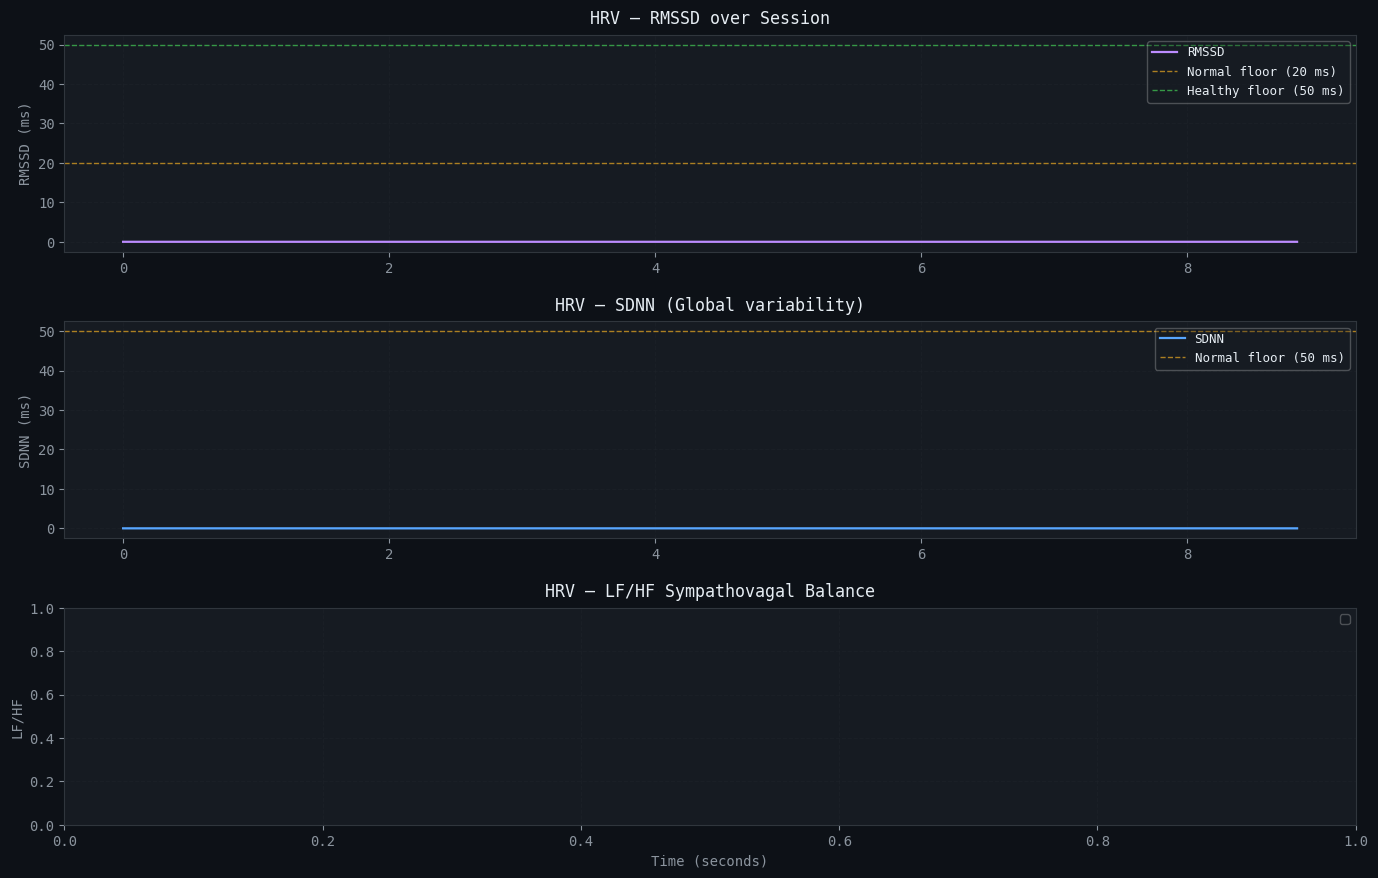

Saved: hrv_analysis.png


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), facecolor='#0d1117')

# RMSSD
ax = axes[0]
ax.plot(df['t_s'], df['rmssd'], color='#bc8cff', linewidth=1.6, label='RMSSD')
ax.axhline(20, color='#d29922', linestyle='--', linewidth=1, alpha=0.8, label='Normal floor (20 ms)')
ax.axhline(50, color='#3fb950', linestyle='--', linewidth=1, alpha=0.8, label='Healthy floor (50 ms)')
ax.fill_between(df['t_s'], df['rmssd'], alpha=0.08, color='#bc8cff')
ax.set_ylabel('RMSSD (ms)', color='#8b949e')
ax.set_title('HRV — RMSSD over Session', color='#e6edf3', fontsize=12, pad=8)
ax.legend(loc='upper right', framealpha=0.3, fontsize=9)
ax.grid(True, alpha=0.4); ax.set_facecolor('#161b22')
ax.tick_params(colors='#8b949e')
for spine in ax.spines.values(): spine.set_color('#30363d')

# SDNN
ax = axes[1]
ax.plot(df['t_s'], df['sdnn'], color='#58a6ff', linewidth=1.6, label='SDNN')
ax.axhline(50, color='#d29922', linestyle='--', linewidth=1, alpha=0.8, label='Normal floor (50 ms)')
ax.fill_between(df['t_s'], df['sdnn'], alpha=0.08, color='#58a6ff')
ax.set_ylabel('SDNN (ms)', color='#8b949e')
ax.set_title('HRV — SDNN (Global variability)', color='#e6edf3', fontsize=12, pad=8)
ax.legend(loc='upper right', framealpha=0.3, fontsize=9)
ax.grid(True, alpha=0.4); ax.set_facecolor('#161b22')
ax.tick_params(colors='#8b949e')
for spine in ax.spines.values(): spine.set_color('#30363d')

# LF/HF ratio
ax = axes[2]
if 'lf_hf_ratio' in df.columns:
    lf_hf = df['lf_hf_ratio'].replace(0, np.nan).dropna()
    t_lf  = df.loc[lf_hf.index, 't_s']
    if len(lf_hf) > 0:
        ax.plot(t_lf, lf_hf, color='#fb923c', linewidth=1.6, label='LF/HF Ratio')
        ax.axhline(0.5, color='#3fb950', linestyle='--', linewidth=1, alpha=0.7, label='Normal low')
        ax.axhline(2.0, color='#d29922', linestyle='--', linewidth=1, alpha=0.7, label='Normal high')
        ax.set_ylim(0, max(lf_hf.max()*1.2, 4))
ax.set_ylabel('LF/HF', color='#8b949e')
ax.set_xlabel('Time (seconds)', color='#8b949e')
ax.set_title('HRV — LF/HF Sympathovagal Balance', color='#e6edf3', fontsize=12, pad=8)
ax.legend(loc='upper right', framealpha=0.3, fontsize=9)
ax.grid(True, alpha=0.4); ax.set_facecolor('#161b22')
ax.tick_params(colors='#8b949e')
for spine in ax.spines.values(): spine.set_color('#30363d')

plt.tight_layout(pad=1.5)
plt.savefig('hrv_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: hrv_analysis.png')


## 6 · Heart-Lung Coupling: RSA · PSI · Cross-Correlation

In [6]:
fig = make_subplots(
    rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.05,
    subplot_titles=[
        'Respiratory Sinus Arrhythmia (RSA) Amplitude — bpm',
        'Phase Synchronisation Index (PSI) — Hilbert Transform',
        'HR × Respiratory Rate Cross-Correlation Peak',
    ]
)

fig.add_trace(go.Scatter(x=df['t_s'], y=df['rsa_amplitude'],
    line=dict(color=C['rsa'], width=1.6), fill='tozeroy',
    fillcolor='rgba(210,153,34,0.08)', name='RSA'), row=1, col=1)

fig.add_trace(go.Scatter(x=df['t_s'], y=df['psi'],
    line=dict(color=C['psi'], width=1.6), fill='tozeroy',
    fillcolor='rgba(63,185,80,0.08)', name='PSI'), row=2, col=1)
fig.add_hline(y=0.6, line_dash='dot', line_color='rgba(63,185,80,0.6)',  line_width=1, row=2, col=1) # type: ignore
fig.add_hline(y=0.3, line_dash='dot', line_color='rgba(210,153,34,0.6)', line_width=1, row=2, col=1) # type: ignore

fig.add_trace(go.Scatter(x=df['t_s'], y=df['xcorr_peak'],
    line=dict(color=C['xcorr'], width=1.6), fill='tozeroy',
    fillcolor='rgba(88,166,255,0.08)', name='XCorr'), row=3, col=1)
fig.add_hline(y=0, line_color='rgba(139,148,158,0.5)', line_width=0.8, row=3, col=1) # type: ignore

fig.update_xaxes(showgrid=True, gridcolor='#21262d', zeroline=False, color='#8b949e', title_text='Time (seconds)', row=3, col=1)
fig.update_yaxes(showgrid=True, gridcolor='#21262d', zeroline=False, color='#8b949e')
fig.update_yaxes(range=[-0.05, 1.05], row=2, col=1)
fig.update_yaxes(range=[-1.05, 1.05], row=3, col=1)
fig.update_layout(
    height=650, showlegend=False,
    paper_bgcolor='#0d1117', plot_bgcolor='#161b22',
    font=dict(color='#8b949e', size=11),
    margin=dict(l=60, r=20, t=40, b=40),
    title=dict(text='Heart-Lung Coupling Metrics · Session Analysis', font=dict(color='#e6edf3', size=15)),
)
fig.update_annotations(font=dict(size=11, color='#8b949e'))
fig.show()

print('\n=== COUPLING SUMMARY ===')
print(f'  RSA amplitude:  mean {df["rsa_amplitude"].mean():.2f} bpm, max {df["rsa_amplitude"].max():.2f} bpm')
print(f'  PSI:            mean {df["psi"].mean():.3f}, max {df["psi"].max():.3f}')
print(f'  XCorr peak:     mean {df["xcorr_peak"].mean():.3f}')
psi_pct = (df['psi'] > 0.6).mean() * 100
print(f'  Time PSI > 0.6: {psi_pct:.1f}% of session (strong phase locking)')



=== COUPLING SUMMARY ===
  RSA amplitude:  mean 0.00 bpm, max 0.00 bpm
  PSI:            mean 0.078, max 0.984
  XCorr peak:     mean 0.000
  Time PSI > 0.6: 0.5% of session (strong phase locking)


## 7 · O₂ Delivery, Stability & Stress Indices

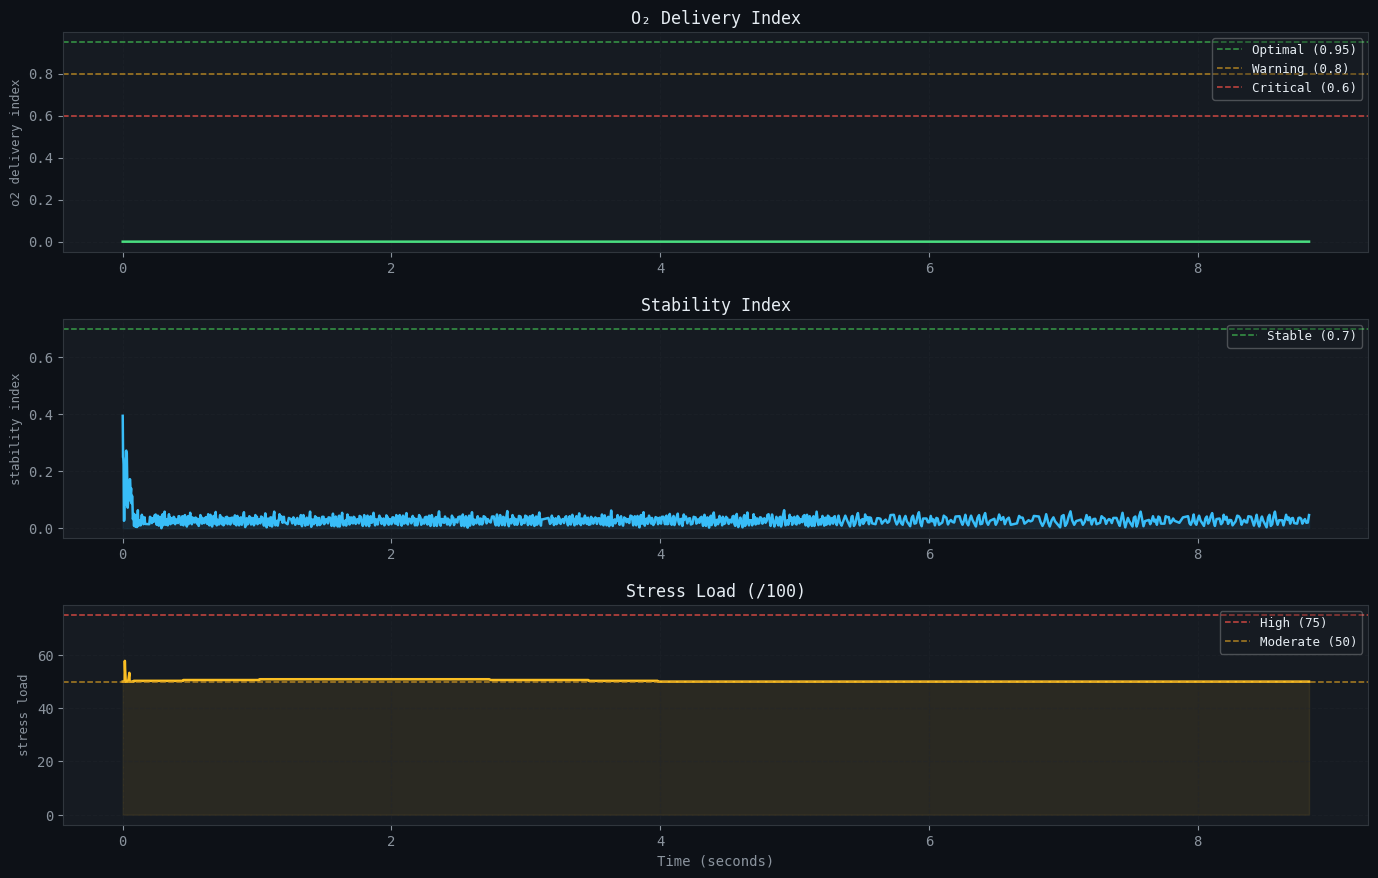

Saved: clinical_indices.png


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), facecolor='#0d1117')

panels = [
    ('o2_delivery_index', 'O₂ Delivery Index', C['o2d'], [(0.95, '#3fb950', 'Optimal'), (0.80, '#d29922', 'Warning'), (0.60, '#f85149', 'Critical')]),
    ('stability_index',   'Stability Index',   '#38bdf8', [(0.70, '#3fb950', 'Stable')]),
    ('stress_load',       'Stress Load (/100)', C['stress'], [(75, '#f85149', 'High'), (50, '#d29922', 'Moderate')]),
]

for ax, (col, title, color, thresholds) in zip(axes, panels):
    ax.plot(df['t_s'], df[col], color=color, linewidth=1.8)
    ax.fill_between(df['t_s'], df[col], alpha=0.09, color=color)
    for y, c, label in thresholds:
        ax.axhline(y, color=c, linestyle='--', linewidth=1.1, alpha=0.8, label=f'{label} ({y})')
    ax.set_title(title, color='#e6edf3', fontsize=12, pad=6)
    ax.set_ylabel(col.replace('_',' '), color='#8b949e', fontsize=9)
    ax.legend(loc='upper right', framealpha=0.3, fontsize=9)
    ax.grid(True, alpha=0.4); ax.set_facecolor('#161b22')
    ax.tick_params(colors='#8b949e')
    for spine in ax.spines.values(): spine.set_color('#30363d')

axes[-1].set_xlabel('Time (seconds)', color='#8b949e')
plt.tight_layout(pad=1.5)
plt.savefig('clinical_indices.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: clinical_indices.png')


## 8 · Alert Frequency and Predictive Performance

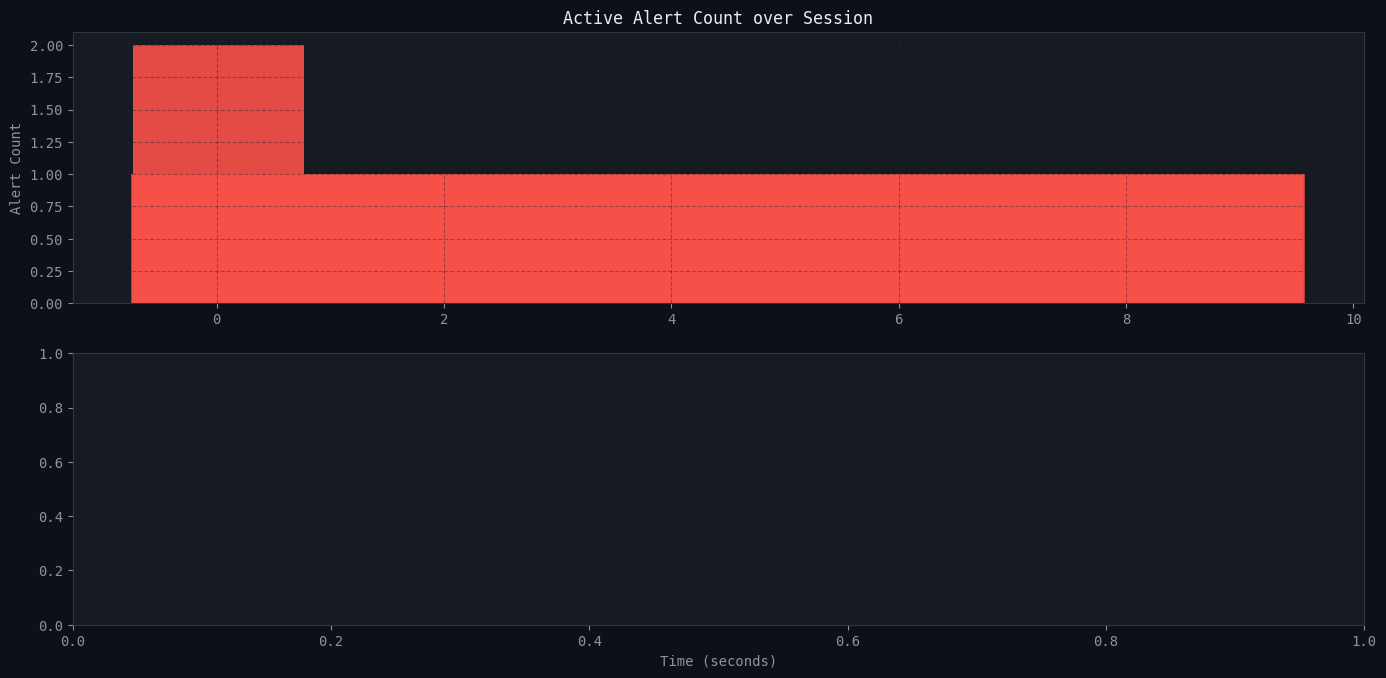

Saved: alert_analysis.png


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), facecolor='#0d1117')

# Alert count over time
ax = axes[0]
if 'n_alerts' in df.columns:
    ax.bar(df['t_s'], df['n_alerts'], width=1.5, color='#f85149', alpha=0.7, label='Active Alerts')
    ax.set_ylabel('Alert Count', color='#8b949e')
    ax.set_title('Active Alert Count over Session', color='#e6edf3', fontsize=12, pad=6)
ax.grid(True, alpha=0.4); ax.set_facecolor('#161b22')
ax.tick_params(colors='#8b949e')
for spine in ax.spines.values(): spine.set_color('#30363d')

# ETA SpO2 to critical (only non-null)
ax = axes[1]
if 'eta_spo2_critical_s' in df.columns:
    eta_s = df[['t_s','eta_spo2_critical_s']].dropna()
    if len(eta_s):
        ax.scatter(eta_s['t_s'], eta_s['eta_spo2_critical_s'],
                   color='#f472b6', s=8, alpha=0.7, label='ETA SpO₂ → critical')
        ax.axhline(60, color='#f85149', linestyle='--', linewidth=1, alpha=0.8, label='60s (CRITICAL threshold)')
        ax.axhline(180, color='#d29922', linestyle='--', linewidth=1, alpha=0.8, label='180s (WARNING threshold)')
        ax.set_ylabel('ETA (seconds)', color='#8b949e')
        ax.set_title('Predictive Alert: ETA to SpO₂ Critical Threshold', color='#e6edf3', fontsize=12, pad=6)
        ax.legend(loc='upper right', framealpha=0.3, fontsize=9)
ax.set_xlabel('Time (seconds)', color='#8b949e')
ax.grid(True, alpha=0.4); ax.set_facecolor('#161b22')
ax.tick_params(colors='#8b949e')
for spine in ax.spines.values(): spine.set_color('#30363d')

plt.tight_layout(pad=1.5)
plt.savefig('alert_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: alert_analysis.png')


## 9 · Correlation Heatmap — Physiological Interdependencies

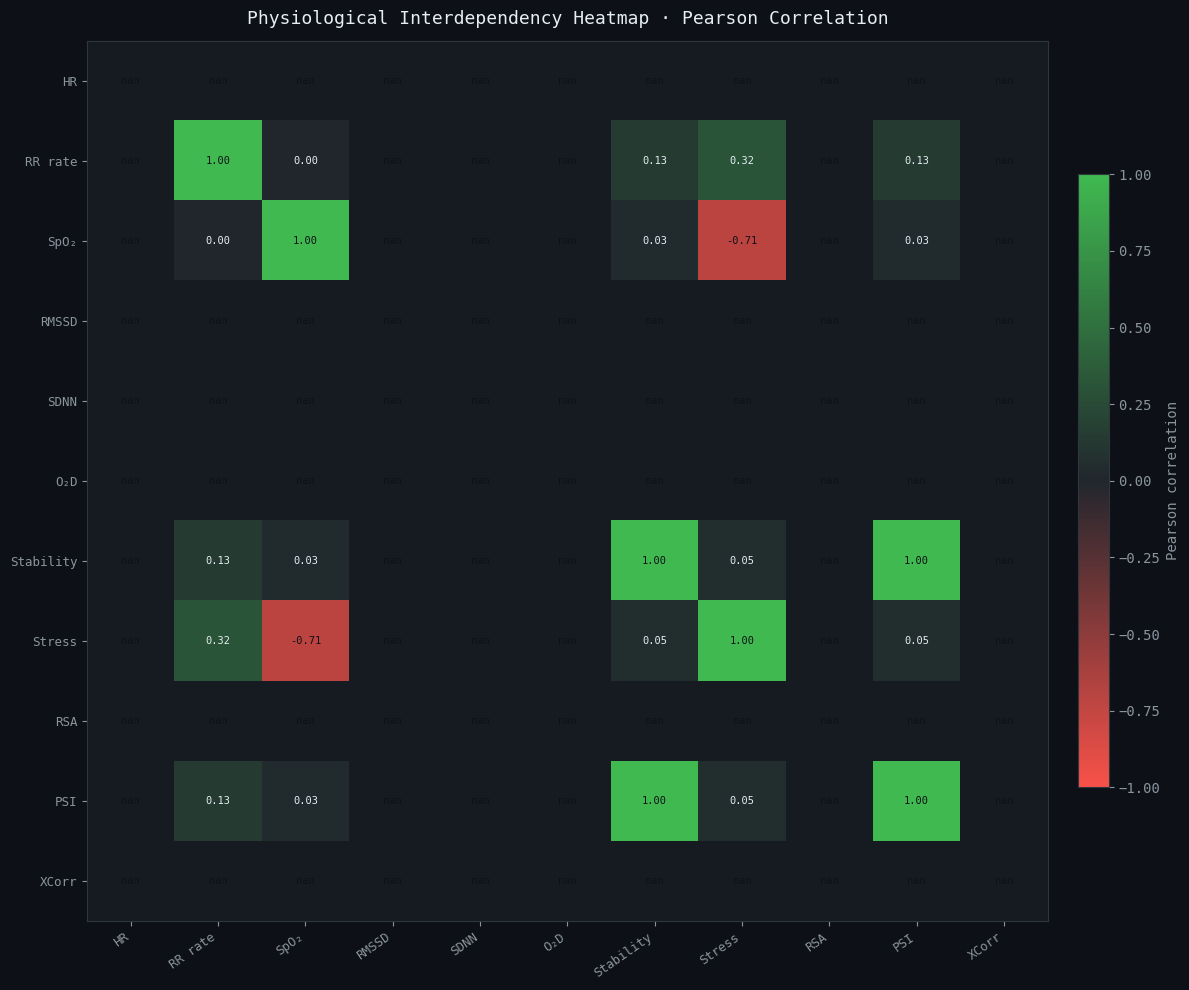

Saved: correlation_heatmap.png

=== KEY PHYSIOLOGICAL CORRELATIONS ===
  heart_rate                × spo2                      → r=+nan (Weak negative)
  heart_rate                × respiratory_rate          → r=+nan (Weak negative)
  spo2                      × o2_delivery_index         → r=+nan (Weak negative)
  rmssd                     × stability_index           → r=+nan (Weak negative)
  psi                       × stability_index           → r=+1.000 (Strong positive)
  rsa_amplitude             × rmssd                     → r=+nan (Weak negative)


In [9]:
import matplotlib.colors as mcolors

corr_cols = ['heart_rate','respiratory_rate','spo2','rmssd','sdnn',
             'o2_delivery_index','stability_index','stress_load',
             'rsa_amplitude','psi','xcorr_peak']

corr_df = df[corr_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(12, 10), facecolor='#0d1117')
ax.set_facecolor('#161b22')

cmap = mcolors.LinearSegmentedColormap.from_list(
    'cpdt', ['#f85149', '#21262d', '#3fb950'], N=256)

im = ax.imshow(corr_df.values, cmap=cmap, vmin=-1, vmax=1, aspect='auto')

labels = ['HR','RR rate','SpO₂','RMSSD','SDNN','O₂D','Stability','Stress','RSA','PSI','XCorr']
ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=35, ha='right', color='#8b949e', fontsize=9)
ax.set_yticklabels(labels, color='#8b949e', fontsize=9)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_df.values[i, j]
        color = '#e6edf3' if abs(val) < 0.6 else '#0d1117'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7.5, color=color)

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.03,
             label='Pearson correlation', orientation='vertical')
ax.set_title('Physiological Interdependency Heatmap · Pearson Correlation',
             color='#e6edf3', fontsize=13, pad=12)
for spine in ax.spines.values(): spine.set_color('#30363d')
ax.tick_params(colors='#8b949e')

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: correlation_heatmap.png')

# Print key correlations
print('\n=== KEY PHYSIOLOGICAL CORRELATIONS ===')
pairs = [('heart_rate','spo2'), ('heart_rate','respiratory_rate'),
         ('spo2','o2_delivery_index'), ('rmssd','stability_index'),
         ('psi','stability_index'), ('rsa_amplitude','rmssd')]
for a, b in pairs:
    if a in corr_df.index and b in corr_df.columns:
        r = corr_df.loc[a, b]
        strength = 'Strong' if abs(r) > 0.7 else 'Moderate' if abs(r) > 0.4 else 'Weak'
        direction = 'positive' if r > 0 else 'negative'
        print(f'  {a:25s} × {b:25s} → r={r:+.3f} ({strength} {direction})')


## 10 · Live Engine Demo — 5-Minute Hypoxia Scenario

In [10]:
cfg = load_config()
engine = TwinEngine(cfg)
engine.start_session(subject_id='NOTEBOOK_DEMO', stay_id='HYPOXIA_SCENARIO')

fs_ecg  = int(cfg.ecg.sampling_rate)
fs_resp = int(cfg.respiratory.sampling_rate)
CHUNK_S = 2.0
DURATION = 300  # 5 min
n_cycles = int(DURATION / CHUNK_S)

records = []

def synth_ecg(n, fs, t0, hr):
    t = np.linspace(t0, t0 + n/fs, n)
    ecg = np.zeros(n)
    for i, ti in enumerate(t):
        ph = (ti * hr / 60.0) % 1.0
        if 0.10 < ph < 0.22: ecg[i] = 0.18*np.sin(np.pi*(ph-0.10)/0.12)
        if 0.25 < ph < 0.35:
            p = (ph-0.25)/0.10
            ecg[i] = np.exp(-((p-0.35)**2)/0.005)
            if p < 0.2: ecg[i] -= 0.3*p
            if p > 0.6: ecg[i] -= 0.15*(p-0.6)
        if 0.45 < ph < 0.65: ecg[i] = 0.28*np.sin(np.pi*(ph-0.45)/0.20)
    return ecg + np.random.normal(0, 0.012, n)

print('Simulating 5-minute hypoxia scenario...')
print(f'  Phases: 0-60s Normal → 60-120s Onset → 120-180s Severe → 180-300s Recovery')

for cyc in range(n_cycles):
    t = cyc * CHUNK_S
    if   t < 60:  hr = 72  + np.random.normal(0,1); spo2 = 97.5 + np.random.normal(0,.3); rr_hz = 0.250
    elif t < 120: hr = 72  + (t-60)/60*20 + np.random.normal(0,2); spo2 = 97.5 - (t-60)/60*8  + np.random.normal(0,.4); rr_hz = 0.25 + (t-60)/60*0.08
    elif t < 180: hr = 92  + (t-120)/60*15 + np.random.normal(0,3); spo2 = 89.5 - (t-120)/60*5 + np.random.normal(0,.5); rr_hz = 0.33 + (t-120)/60*0.05
    else:         frac = min(1.0,(t-180)/120); hr = 107 - frac*27 + np.random.normal(0,2); spo2 = 84.5 + frac*13 + np.random.normal(0,.4); rr_hz = 0.38 - frac*0.13

    n_e = int(fs_ecg*CHUNK_S); n_r = int(fs_resp*CHUNK_S)
    t_r = np.linspace(t, t+CHUNK_S, n_r)
    ecg_c  = synth_ecg(n_e, fs_ecg, t, float(np.clip(hr, 30, 200)))
    resp_c = np.sin(2*np.pi*rr_hz*t_r) + np.random.normal(0,.02,n_r)
    spo2_c = np.array([float(np.clip(spo2, 50, 100))])

    state = engine.ingest(ecg_c, resp_c, spo2_c)
    records.append(state.summary_dict())

demo_df = pd.DataFrame(records)
demo_df['t_s'] = np.arange(len(demo_df)) * CHUNK_S
print(f'✓ Simulation complete: {len(demo_df)} cycles, {engine.cycle_count} engine calls')

# Phase annotation
demo_df['phase'] = pd.cut(demo_df['t_s'],
    bins=[-1,60,120,180,301],
    labels=['Baseline','Hypoxia Onset','Severe Hypoxia','Recovery'])

print('\nPhase statistics:')
display(demo_df.groupby('phase')[['heart_rate','spo2','o2_delivery_index','stress_load']].mean().round(2))


2026-05-21 01:52:37.098 | INFO     | src.prediction.trend_predictor:_build_lstm:134 - LSTM predictor initialised
2026-05-21 01:52:37.099 | INFO     | src.core.twin_engine:__init__:73 - TwinEngine initialised with config.
2026-05-21 01:52:37.099 | INFO     | src.core.twin_engine:start_session:87 - Session started | subject=NOTEBOOK_DEMO | stay=HYPOXIA_SCENARIO
2026-05-21 01:52:37.111 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:37.117 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:37.124 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:37.131 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:37.139 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:

Simulating 5-minute hypoxia scenario...
  Phases: 0-60s Normal → 60-120s Onset → 120-180s Severe → 180-300s Recovery
Detected peaks: 3
Peak locations: [ 40 136 242]
Detected peaks: 2
Peak locations: [ 79 203]
Detected peaks: 2
Peak locations: [ 47 144]
Detected peaks: 3
Peak locations: [ 39  98 218]
Detected peaks: 3
Peak locations: [ 38  84 180]
Detected peaks: 2
Peak locations: [125 236]
Detected peaks: 2
Peak locations: [131 237]
Detected peaks: 2
Peak locations: [ 44 182]
Detected peaks: 2
Peak locations: [136 241]
Detected peaks: 2
Peak locations: [ 42 144]
Detected peaks: 3
Peak locations: [ 40  81 187]
Detected peaks: 3
Peak locations: [ 56  99 203]
Detected peaks: 2
Peak locations: [ 40 155]
Detected peaks: 3
Peak locations: [ 42  96 214]
Detected peaks: 2
Peak locations: [100 219]
Detected peaks: 3
Peak locations: [ 39  91 217]
Detected peaks: 3
Peak locations: [ 38  76 177]
Detected peaks: 2
Peak locations: [ 38 171]
Detected peaks: 3
Peak locations: [ 40 108 202]
Detected pe

2026-05-21 01:52:37.310 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:37.316 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:37.325 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:37.332 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:37.340 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:37.347 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:37.355 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:37.

Detected peaks: 2
Peak locations: [ 41 162]
Detected peaks: 2
Peak locations: [126 238]
Detected peaks: 2
Peak locations: [ 41 148]
Detected peaks: 3
Peak locations: [ 42 148 247]
Detected peaks: 2
Peak locations: [128 228]
Detected peaks: 3
Peak locations: [ 43  85 202]
Detected peaks: 3
Peak locations: [ 38  87 213]
Detected peaks: 2
Peak locations: [ 46 156]
Detected peaks: 3
Peak locations: [ 38  76 172]
Detected peaks: 3
Peak locations: [ 39  85 182]
Detected peaks: 2
Peak locations: [ 44 160]
Detected peaks: 2
Peak locations: [ 41 159]
Detected peaks: 2
Peak locations: [ 41 168]
Detected peaks: 3
Peak locations: [ 49 144 233]
Detected peaks: 3
Peak locations: [ 39 125 216]
Detected peaks: 2
Peak locations: [105 206]
Detected peaks: 2
Peak locations: [ 64 176]
Detected peaks: 2
Peak locations: [ 75 183]
Detected peaks: 2
Peak locations: [ 50 161]
Detected peaks: 2
Peak locations: [100 194]
Detected peaks: 2
Peak locations: [ 89 174]
Detected peaks: 2
Peak locations: [ 45 170]
Dete

2026-05-21 01:52:37.522 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:37.539 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:37.547 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:37.555 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:37.562 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:37.572 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:37.587 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:37.

...

2026-05-21 01:52:38.396 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:38.409 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:38.424 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:38.436 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:38.447 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:38.459 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:38.472 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:38.

Detected peaks: 2
Peak locations: [106 178]
Detected peaks: 3
Peak locations: [ 62 158 236]
Detected peaks: 3
Peak locations: [ 45 114 203]
Detected peaks: 2
Peak locations: [106 180]
Detected peaks: 3
Peak locations: [ 55 144 226]
Detected peaks: 3
Peak locations: [ 78 163 245]
Detected peaks: 2
Peak locations: [116 197]
Detected peaks: 3
Peak locations: [ 41 134 224]
Detected peaks: 2
Peak locations: [ 98 183]
Detected peaks: 3
Peak locations: [ 46  84 174]
Detected peaks: 2
Peak locations: [ 97 176]
Detected peaks: 2
Peak locations: [112 200]
Detected peaks: 3
Peak locations: [ 38 144 222]
Detected peaks: 3
Peak locations: [ 38 147 235]
Detected peaks: 3
Peak locations: [ 41 141 217]
Detected peaks: 2
Peak locations: [ 79 174]
Detected peaks: 3
Peak locations: [ 38  96 184]


2026-05-21 01:52:38.599 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:38.612 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:38.625 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:38.638 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:38.649 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:38.662 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:38.678 | DEBUG    | src.signals.ecg_processor:_hrv_frequency:281 - HRV freq error: module 'numpy' has no attribute 'trapz'
2026-05-21 01:52:38.

Detected peaks: 3
Peak locations: [ 45  95 182]
Detected peaks: 3
Peak locations: [ 41 158 237]
Detected peaks: 3
Peak locations: [ 56 140 231]
Detected peaks: 2
Peak locations: [121 216]
Detected peaks: 3
Peak locations: [ 41 131 218]
Detected peaks: 3
Peak locations: [ 41 130 215]
Detected peaks: 3
Peak locations: [ 41  91 188]
Detected peaks: 3
Peak locations: [ 41  92 194]
Detected peaks: 3
Peak locations: [ 45 124 218]
Detected peaks: 2
Peak locations: [113 201]
Detected peaks: 2
Peak locations: [118 200]
Detected peaks: 3
Peak locations: [ 58 151 239]
Detected peaks: 3
Peak locations: [ 38 150 234]
Detected peaks: 3
Peak locations: [ 47  90 183]
Detected peaks: 2
Peak locations: [106 189]
✓ Simulation complete: 150 cycles, 150 engine calls

Phase statistics:


,heart_rate,spo2,o2_delivery_index,stress_load
phase,,,,
Baseline,69.57,97.55,1.08,3.08
Hypoxia Onset,70.71,93.31,1.05,14.07
Severe Hypoxia,75.62,86.90,1.05,35.20
Recovery,82.98,91.02,1.21,28.82


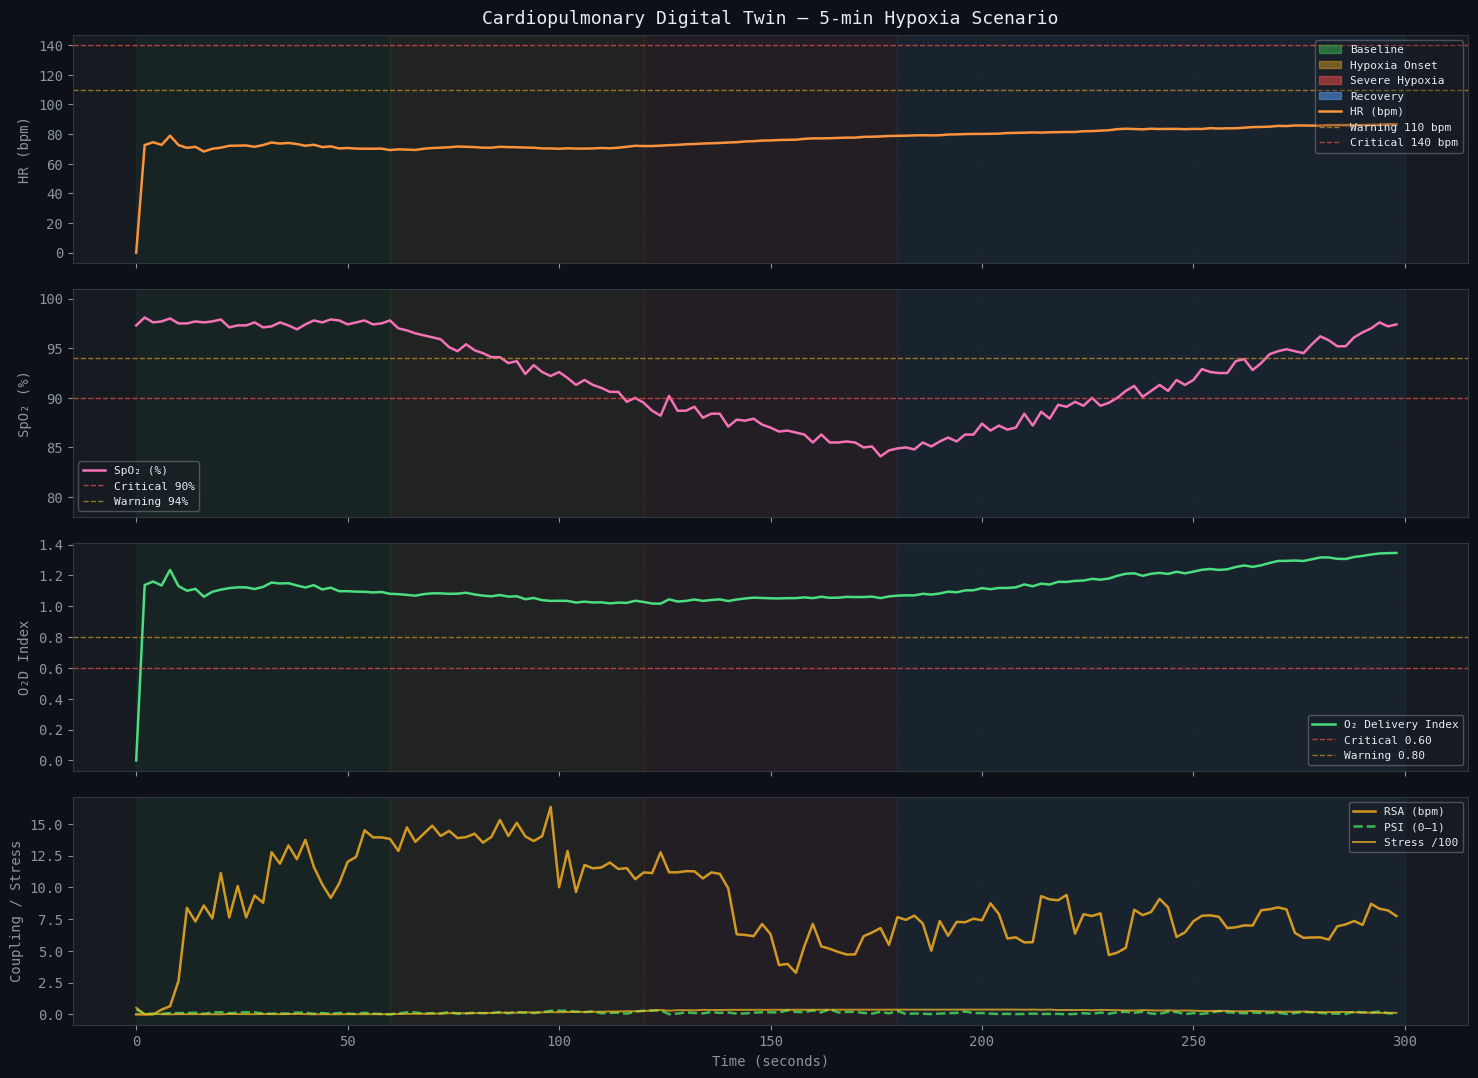

Saved: hypoxia_scenario.png


In [11]:
# Visualise the hypoxia scenario
fig, axes = plt.subplots(4, 1, figsize=(15, 11), facecolor='#0d1117', sharex=True)

phase_colors = {'Baseline':'#3fb950','Hypoxia Onset':'#d29922',
                'Severe Hypoxia':'#f85149','Recovery':'#58a6ff'}

# Shade phase regions
phase_ranges = [(0,60,'Baseline'),(60,120,'Hypoxia Onset'),(120,180,'Severe Hypoxia'),(180,300,'Recovery')]

for ax in axes:
    ax.set_facecolor('#161b22'); ax.grid(True, alpha=0.35); ax.tick_params(colors='#8b949e')
    for spine in ax.spines.values(): spine.set_color('#30363d')
    for lo, hi, ph in phase_ranges:
        ax.axvspan(lo, hi, alpha=0.06, color=phase_colors[ph])

axes[0].plot(demo_df['t_s'], demo_df['heart_rate'],    color=C['hr'],    lw=1.8, label='HR (bpm)')
axes[0].set_ylabel('HR (bpm)', color='#8b949e')
axes[0].set_title('Cardiopulmonary Digital Twin — 5-min Hypoxia Scenario', color='#e6edf3', fontsize=13, pad=8)
axes[0].axhline(110, color='#d29922', ls='--', lw=1, alpha=0.7, label='Warning 110 bpm')
axes[0].axhline(140, color='#f85149', ls='--', lw=1, alpha=0.7, label='Critical 140 bpm')
axes[0].legend(fontsize=8, framealpha=0.3, loc='upper left')

axes[1].plot(demo_df['t_s'], demo_df['spo2'],           color=C['spo2'], lw=1.8, label='SpO₂ (%)')
axes[1].set_ylabel('SpO₂ (%)', color='#8b949e')
axes[1].axhline(90, color='#f85149', ls='--', lw=1, alpha=0.7, label='Critical 90%')
axes[1].axhline(94, color='#d29922', ls='--', lw=1, alpha=0.7, label='Warning 94%')
axes[1].set_ylim(78, 101)
axes[1].legend(fontsize=8, framealpha=0.3, loc='lower left')

axes[2].plot(demo_df['t_s'], demo_df['o2_delivery_index'], color=C['o2d'], lw=1.8, label='O₂ Delivery Index')
axes[2].set_ylabel('O₂D Index', color='#8b949e')
axes[2].axhline(0.60, color='#f85149', ls='--', lw=1, alpha=0.7, label='Critical 0.60')
axes[2].axhline(0.80, color='#d29922', ls='--', lw=1, alpha=0.7, label='Warning 0.80')
axes[2].legend(fontsize=8, framealpha=0.3)

axes[3].plot(demo_df['t_s'], demo_df['rsa_amplitude'], color=C['rsa'], lw=1.8, label='RSA (bpm)')
axes[3].plot(demo_df['t_s'], demo_df['psi'],           color=C['psi'], lw=1.8, label='PSI (0–1)', ls='--')
axes[3].plot(demo_df['t_s'], demo_df['stress_load']/100, color=C['stress'], lw=1.4, label='Stress /100', alpha=0.7)
axes[3].set_ylabel('Coupling / Stress', color='#8b949e')
axes[3].set_xlabel('Time (seconds)', color='#8b949e')
axes[3].legend(fontsize=8, framealpha=0.3)

# Phase legend
patches = [mpatches.Patch(color=v, alpha=0.5, label=k) for k,v in phase_colors.items()]
axes[0].legend(handles=patches + axes[0].get_legend_handles_labels()[0],
               fontsize=8, framealpha=0.3, loc='upper right')

plt.tight_layout(pad=1.5)
plt.savefig('hypoxia_scenario.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: hypoxia_scenario.png')


## 11 · Clinical Report Summary

In [12]:
print('=' * 70)
print('  CARDIOPULMONARY DIGITAL TWIN — CLINICAL REPORT')
print('  MIMIC-IV Research Analysis')
print('=' * 70)

try:
    _df = df  # Use session log if loaded
    dur = _df['t_s'].max()
except:
    _df = demo_df; dur = 300

print(f'\n  SESSION DURATION : {dur:.0f} seconds ({dur/60:.1f} minutes)')
print(f'  RECORDS          : {len(_df)}')
print()
print('  VITAL SIGNS')
print(f'  ├─ Heart Rate       : {_df["heart_rate"].mean():.1f} ± {_df["heart_rate"].std():.1f} bpm  (range {_df["heart_rate"].min():.0f}–{_df["heart_rate"].max():.0f})')
print(f'  ├─ Respiratory Rate : {_df["respiratory_rate"].mean():.1f} ± {_df["respiratory_rate"].std():.1f} br/min')
print(f'  └─ SpO₂             : {_df["spo2"].mean():.1f} ± {_df["spo2"].std():.1f}%  (nadir {_df["spo2"].min():.1f}%)')
print()
print('  HRV ANALYSIS')
print(f'  ├─ RMSSD (mean)     : {_df["rmssd"].mean():.1f} ms  ({"Normal" if _df["rmssd"].mean()>=20 else "Reduced"})')
print(f'  └─ SDNN (mean)      : {_df["sdnn"].mean():.1f} ms  ({"Normal" if _df["sdnn"].mean()>=50 else "Reduced"})')
print()
print('  HEART-LUNG COUPLING')
print(f'  ├─ RSA Amplitude    : {_df["rsa_amplitude"].mean():.2f} bpm (mean)')
psi_m = _df['psi'].mean()
psi_s = 'Strong' if psi_m>0.6 else 'Moderate' if psi_m>0.3 else 'Weak'
print(f'  ├─ PSI (mean)       : {psi_m:.3f}  [{psi_s} phase synchronisation]')
print(f'  └─ XCorr Peak       : {_df["xcorr_peak"].mean():.3f}')
print()
print('  DERIVED INDICES')
o2d_m = _df['o2_delivery_index'].mean()
o2d_s = 'Adequate' if o2d_m>=0.95 else 'Reduced' if o2d_m>=0.80 else 'CRITICAL'
print(f'  ├─ O₂ Delivery      : {o2d_m:.3f} mean  [{o2d_s}]  nadir {_df["o2_delivery_index"].min():.3f}')
print(f'  ├─ Stability Index  : {_df["stability_index"].mean():.3f} mean')
print(f'  └─ Stress Load      : {_df["stress_load"].mean():.1f}/100 mean  (peak {_df["stress_load"].max():.0f})')
print()
if 'n_alerts' in _df.columns:
    total_alerts = int(_df['n_alerts'].sum())
    alert_rate = _df['n_alerts'].mean()
    print(f'  ALERTING')
    print(f'  ├─ Total alert events : {total_alerts}')
    print(f'  └─ Alert rate         : {alert_rate:.2f} alerts/record')
print()
print('  Generated by: Cardiopulmonary Digital Twin v1.0')
print('  Data: MIMIC-IV Waveform Database · PhysioNet')
print('=' * 70)


  CARDIOPULMONARY DIGITAL TWIN — CLINICAL REPORT
  MIMIC-IV Research Analysis

  SESSION DURATION : 9 seconds (0.1 minutes)
  RECORDS          : 1200

  VITAL SIGNS
  ├─ Heart Rate       : 0.0 ± 0.0 bpm  (range 0–0)
  ├─ Respiratory Rate : 15.6 ± 0.6 br/min
  └─ SpO₂             : 98.0 ± 0.2%  (nadir 97.7%)

  HRV ANALYSIS
  ├─ RMSSD (mean)     : 0.0 ms  (Reduced)
  └─ SDNN (mean)      : 0.0 ms  (Reduced)

  HEART-LUNG COUPLING
  ├─ RSA Amplitude    : 0.00 bpm (mean)
  ├─ PSI (mean)       : 0.078  [Weak phase synchronisation]
  └─ XCorr Peak       : 0.000

  DERIVED INDICES
  ├─ O₂ Delivery      : 0.000 mean  [CRITICAL]  nadir 0.000
  ├─ Stability Index  : 0.031 mean
  └─ Stress Load      : 50.4/100 mean  (peak 58)

  ALERTING
  ├─ Total alert events : 1202
  └─ Alert rate         : 1.00 alerts/record

  Generated by: Cardiopulmonary Digital Twin v1.0
  Data: MIMIC-IV Waveform Database · PhysioNet
